# Classifying the 100K H&E dataset - 2

Method: Stanford CS231n Regularization and Optimization

Author: Marissa Esteban

Date: 04/28/2026

Data: Kather, Jakob Nikolas, Halama, Niels, & Marx, Alexander. (2018). 100,000 histological images of human colorectal cancer and healthy tissue (v0.1) [Data set]. Zenodo. https://doi.org/10.5281/zenodo.1214456


In [8]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from torch import nn
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor, Lambda
from torch.utils.data import DataLoader

In [18]:
# importing the data

batch_size = 64

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(
    root="D:\\me2982@cumc.columbia.edu\\bianca\\NCT-CRC-HE-100K",   # path to the unzipped folder
    # root = "/Volumes/PortableSSD/me2982@cumc.columbia.edu/bianca/NCT-CRC-HE-100K",
    transform=transform
)

val_dataset = datasets.ImageFolder(
    root="D:\\me2982@cumc.columbia.edu\\bianca\\CRC-VAL-HE-7K",
    # root = "/Volumes/PortableSSD/me2982@cumc.columbia.edu/bianca/CRC-VAL-HE-7K",
    transform=transform
)


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=True, num_workers=0)

classes = train_dataset.classes

# Check it loaded correctly
print(train_dataset.classes)   # ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
print(len(train_dataset))      # 100000

['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
100000


In [10]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [11]:
# assuming the input is 224 x 224

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 53 * 53, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net().to(device)
print(net)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=44944, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


##### Adding L2 regularization to the loss

 lambda * sum(weights^2)

In [12]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [13]:
# training the network
train_losses = []
val_losses = []
val_accuracy = []

l2_lambda = 0.01  # regularization strength

for epoch in range(10):  # loop over the dataset multiple times

    running_loss = 0.0
    epoch_loss = 0.0
    net.train()
    for i, data in enumerate(train_loader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward
        outputs = net(inputs)
        loss = criterion(outputs, labels)

        # L2 regularization
        weights = 0
        for param in net.parameters():
            weights += torch.sum(param ** 2)

        # backward + optimize
        l2_loss = loss + l2_lambda * weights
        l2_loss.backward()
        optimizer.step()

        # update loss accumulators (for printing and evaluating)
        running_loss += l2_loss.item()
        epoch_loss += l2_loss.item()

        if i % 200 == 199:    # print every 200 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 200:.3f}')
            running_loss = 0.0
        

    train_losses.append(epoch_loss / len(train_loader))
    
    # --- validation ---
    net.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_losses.append(val_loss / len(val_loader))
    val_accuracy.append(correct / total)
    print(f'Epoch {epoch + 1} complete | val loss: {val_losses[-1]:.3f}, val accuracy: {val_accuracy[-1]:.3f}')

print('Finished Training')

[1,   200] loss: 2.685
[1,   400] loss: 2.054
[1,   600] loss: 1.807
[1,   800] loss: 1.710
[1,  1000] loss: 1.608
[1,  1200] loss: 1.518
[1,  1400] loss: 1.475
Epoch 1 complete | val loss: 0.837, val accuracy: 0.687
[2,   200] loss: 1.356
[2,   400] loss: 1.322
[2,   600] loss: 1.289
[2,   800] loss: 1.236
[2,  1000] loss: 1.213
[2,  1200] loss: 1.158
[2,  1400] loss: 1.122
Epoch 2 complete | val loss: 0.752, val accuracy: 0.716
[3,   200] loss: 1.079
[3,   400] loss: 1.055
[3,   600] loss: 1.049
[3,   800] loss: 1.009
[3,  1000] loss: 1.003
[3,  1200] loss: 0.987
[3,  1400] loss: 0.964
Epoch 3 complete | val loss: 0.688, val accuracy: 0.776
[4,   200] loss: 0.915
[4,   400] loss: 0.921
[4,   600] loss: 0.915
[4,   800] loss: 0.895
[4,  1000] loss: 0.886
[4,  1200] loss: 0.897
[4,  1400] loss: 0.869
Epoch 4 complete | val loss: 0.596, val accuracy: 0.816
[5,   200] loss: 0.854
[5,   400] loss: 0.844
[5,   600] loss: 0.824
[5,   800] loss: 0.811
[5,  1000] loss: 0.812
[5,  1200] loss: 

In [ ]:
import json

# save training and validation losses and accuracy to a json file
with open('D:\\me2982@cumc.columbia.edu\\bianca\\models\\losses_2.json', "w") as f:
    json.dump({
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accuracy": val_accuracy
    }, f)

# saving our model
PATH = 'D:\\me2982@cumc.columbia.edu\\bianca\\models\\first_nn_2.pth'
# PATH = "/Volumes/PortableSSD/me2982@cumc.columbia.edu/bianca/models/first_nn_2.pth"
torch.save(net.state_dict(), PATH)

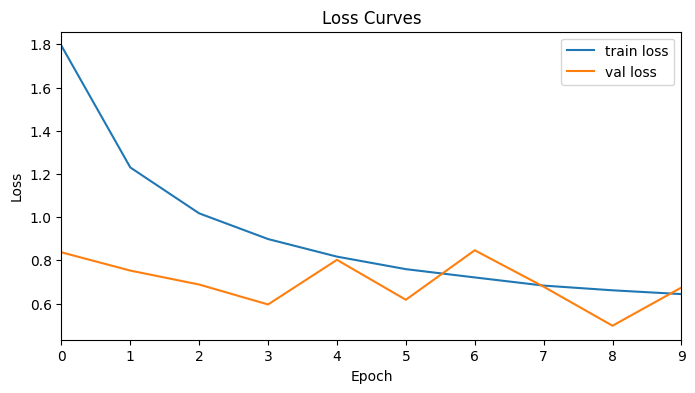

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='train loss')
plt.plot(val_losses, label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')
plt.xlim(0, 9)
plt.show()

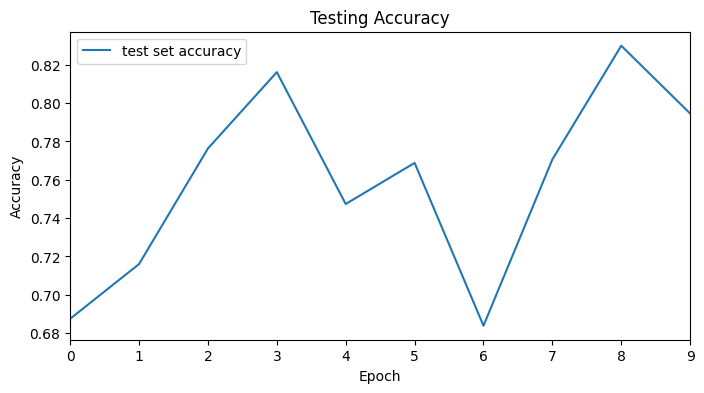

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(val_accuracy, label='test set accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Testing Accuracy')
plt.xlim(0, 9)
plt.show()

In [19]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in val_loader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 7000 validation images: {100 * correct // total} %')

Accuracy of the network on the 7000 validation images: 79 %


In [29]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

y_true = []
y_pred = []

# again no gradients needed
with torch.no_grad():
    for data in val_loader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            y_true.append(classes[label])
            y_pred.append(classes[prediction])
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: ADI   is 97.7 %
Accuracy for class: BACK  is 100.0 %
Accuracy for class: DEB   is 73.7 %
Accuracy for class: LYM   is 99.1 %
Accuracy for class: MUC   is 64.9 %
Accuracy for class: MUS   is 71.1 %
Accuracy for class: NORM  is 73.7 %
Accuracy for class: STR   is 32.5 %
Accuracy for class: TUM   is 72.7 %


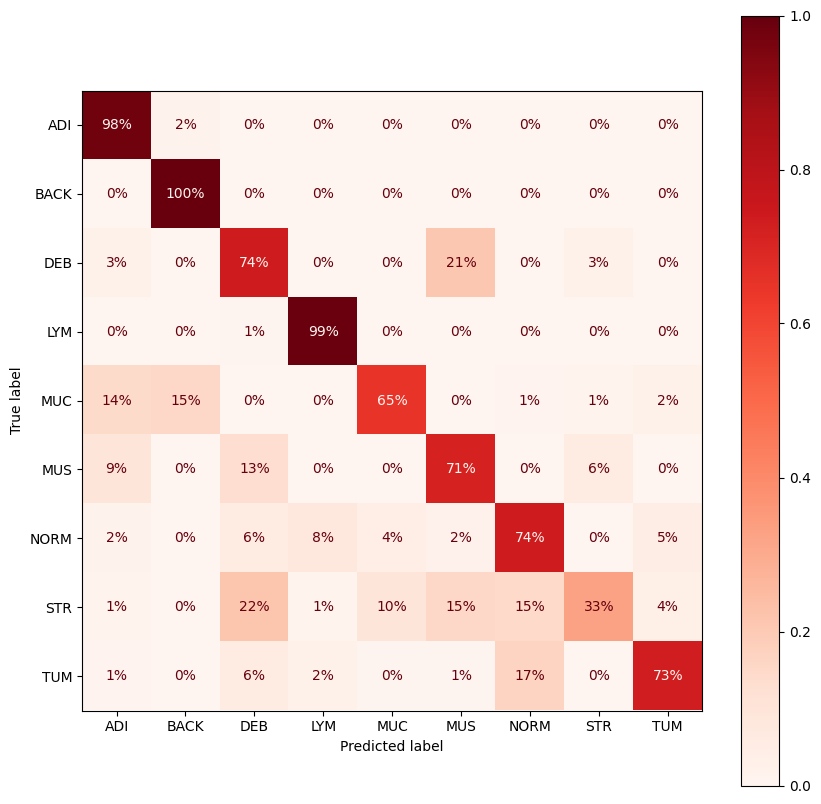

In [33]:
# confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred, labels=classes, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Reds, ax=ax, values_format='.0%')

## Visualizing embeddings using uMAP

In [21]:
class cnnEmbedding(nn.Module):
    """
    A copy of the Net class, but without the final layer 
    to use as an embedding model
    """

    def __init__(self, net):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 53 * 53, 120)
        self.fc2 = nn.Linear(120, 84)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        return x

In [22]:
net.eval()

embedding_net = cnnEmbedding(net).to(device)
embedding_net.eval()

all_embeddings = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        emb = embedding_net(images)          # [32, 84]
        all_embeddings.append(emb.cpu())
        all_labels.append(labels)

# concatenate list of tensors into one matrix
X = torch.cat(all_embeddings).numpy()   # [7180, 84]
y = torch.cat(all_labels).numpy()       # [7180]

print(X.shape)  # (7180, 84)
print(y.shape)  # (7180,)

(7180, 84)
(7180,)


In [24]:
import umap
import umap.plot
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

c:\Users\Marissa Esteban\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Marissa Esteban\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\Marissa Esteban\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg,

In [27]:
mapper = umap.UMAP(n_neighbors=10, min_dist=0.1, n_components=2).fit(X)

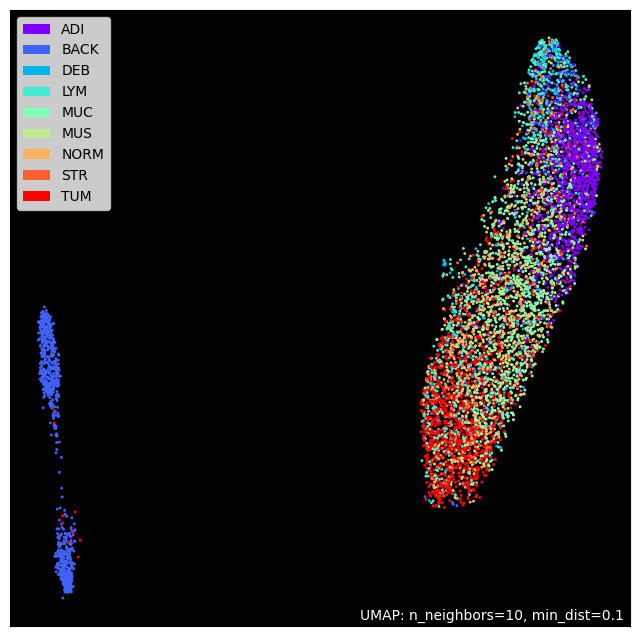

In [28]:
classes = ['ADI','BACK','DEB','LYM','MUC','MUS','NORM','STR','TUM']
y_named = np.array([classes[i] for i in y])

umap.plot.points(mapper, labels=y_named, theme='fire')
plt.show()